<br>

<div dir=ltr align=center>
<img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width=150 height=150> <br>
<font color=000000 size=3>
<p align="center"><br>
  <strong>Sharif University of Technology</strong><br>
  Department of Industrial Engineering
</p>

<font color=000000 size=3>
</br>
<p align="center"><strong>Project - Phase 2</strong></p>
</br>
<p align="center">
  Course: <strong>Transportation Planning</strong><br>
  Instructor: <strong>Dr. Erfan Hassannayebi</strong>
</p>

</br>
<p align="center">
  <strong>Ghazal Zolfi Moselo</strong><br>
  401104146
<br><br>
  <strong>MohammadMahdi Montazeri Hedesh</strong><br>
  401104479
</p>

</br>
<p align="center">Semester: Fall 2025</p>

# Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import pulp
from scipy.stats import chi2_contingency

# Import Dataset

In [2]:
data = pd.read_csv("rideshare_kaggle.csv")

In [3]:
data

,id,hour,day,month,source,destination,cab_type,product_id,name,price,...,pressure,windBearing,cloudCover,uvIndex,ozone,moonPhase,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,9,16,12,Haymarket Square,North Station,Lyft,lyft_line,Shared,5.0,...,1021.98,57,0.72,0,303.8,0.30,39.89,43.68,33.73,38.07
1,4bd23055-6827-41c6-b23b-3c491f24e74d,2,27,11,Haymarket Square,North Station,Lyft,lyft_premier,Lux,11.0,...,1003.97,90,1.00,0,291.1,0.64,40.49,47.30,36.20,43.92
2,981a3613-77af-4620-a42a-0c0866077d1e,1,28,11,Haymarket Square,North Station,Lyft,lyft,Lyft,7.0,...,992.28,240,0.03,0,315.7,0.68,35.36,47.55,31.04,44.12
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,4,30,11,Haymarket Square,North Station,Lyft,lyft_luxsuv,Lux Black XL,26.0,...,1013.73,310,0.00,0,291.1,0.75,34.67,45.03,30.30,38.53
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,3,29,11,Haymarket Square,North Station,Lyft,lyft_plus,Lyft XL,9.0,...,998.36,303,0.44,0,347.7,0.72,33.10,42.18,29.11,35.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
693066,616d3611-1820-450a-9845-a9ff304a4842,23,1,12,West End,North End,Uber,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL,13.0,...,1023.57,133,0.31,0,271.5,0.82,31.42,44.76,27.77,44.09
693067,633a3fc3-1f86-4b9e-9d48-2b7132112341,23,1,12,West End,North End,Uber,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX,9.5,...,1023.57,133,0.31,0,271.5,0.82,31.42,44.76,27.77,44.09
693068,64d451d0-639f-47a4-9b7c-6fd92fbd264f,23,1,12,West End,North End,Uber,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi,NaN,...,1023.57,133,0.31,0,271.5,0.82,31.42,44.76,27.77,44.09
693069,727e5f07-a96b-4ad1-a2c7-9abc3ad55b4e,23,1,12,West End,North End,Uber,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV,27.0,...,1023.57,133,0.31,0,271.5,0.82,31.42,44.76,27.77,44.09


# Question 1:

## Part 1:

In [4]:
od_matrix = (
    data
    .groupby(['source', 'destination'])
    .size()
    .unstack(fill_value=0)
)

In [5]:
od_matrix

destination,Back Bay,Beacon Hill,Boston University,Fenway,Financial District,Haymarket Square,North End,North Station,Northeastern University,South Station,Theatre District,West End
source,,,,,,,,,,,,
Back Bay,0,0,9435,9469,0,9605,10225,0,9584,9474,0,0
Beacon Hill,0,0,9222,9436,0,9566,10039,0,9684,9456,0,0
Boston University,9435,9215,0,0,9711,0,0,9480,0,0,9967,9956
Fenway,9476,9436,0,0,9681,0,0,9751,0,0,9248,10165
Financial District,0,0,9711,9695,0,10133,9339,0,9627,10352,0,0
Haymarket Square,9605,9566,0,0,10134,0,0,9634,0,0,9641,9156
North End,10225,10039,0,0,9339,0,0,9422,0,0,9525,9213
North Station,0,0,9480,9751,0,9641,9421,0,9679,9146,0,0
Northeastern University,9579,9690,0,0,9634,0,0,9679,0,0,9644,9530


## Part 2:

In [6]:
data['date'] = pd.to_datetime({
    'year': 2018,
    'month': data['month'],
    'day': data['day']
})

data['weekday'] = data['date'].dt.dayofweek  # 0 = Monday
weekday_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
data['weekday_name'] = data['weekday'].map(weekday_map)

zones = sorted(set(data['source']).union(set(data['destination'])))

days_count = data.groupby('weekday_name')['date'].nunique()

od_by_weekday_avg = {}

for day in data['weekday_name'].unique():
    total_od = (
        data[data['weekday_name'] == day]
        .groupby(['source', 'destination'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=zones, columns=zones, fill_value=0)
    )
    od_by_weekday_avg[day] = total_od / days_count[day]

In [7]:
od_by_weekday_avg['Sat']

destination,Back Bay,Beacon Hill,Boston University,Fenway,Financial District,Haymarket Square,North End,North Station,Northeastern University,South Station,Theatre District,West End
source,,,,,,,,,,,,
Back Bay,0.0,0.0,619.0,616.5,0.0,669.0,617.0,0.0,598.0,674.0,0.0,0.0
Beacon Hill,0.0,0.0,592.0,644.5,0.0,610.0,624.0,0.0,630.0,602.5,0.0,0.0
Boston University,611.0,609.5,0.0,0.0,652.0,0.0,0.0,632.5,0.0,0.0,657.0,641.5
Fenway,591.0,604.5,0.0,0.0,565.5,0.0,0.0,631.5,0.0,0.0,599.5,695.5
Financial District,0.0,0.0,607.5,598.0,0.0,684.0,633.0,0.0,632.5,655.5,0.0,0.0
Haymarket Square,625.5,641.5,0.0,0.0,653.5,0.0,0.0,664.5,0.0,0.0,642.0,692.5
North End,608.0,621.0,0.0,0.0,628.5,0.0,0.0,598.5,0.0,0.0,648.0,606.0
North Station,0.0,0.0,623.0,693.0,0.0,632.5,617.5,0.0,646.0,587.5,0.0,0.0
Northeastern University,605.0,608.5,0.0,0.0,690.5,0.0,0.0,600.5,0.0,0.0,603.5,633.5


In [8]:
od_by_weekday_avg['Sun']

destination,Back Bay,Beacon Hill,Boston University,Fenway,Financial District,Haymarket Square,North End,North Station,Northeastern University,South Station,Theatre District,West End
source,,,,,,,,,,,,
Back Bay,0.000000,0.000000,401.000000,451.000000,0.000000,431.333333,465.666667,0.000000,421.000000,436.000000,0.000000,0.000000
Beacon Hill,0.000000,0.000000,402.000000,430.666667,0.000000,415.333333,434.000000,0.000000,429.000000,401.000000,0.000000,0.000000
Boston University,412.666667,400.333333,0.000000,0.000000,424.000000,0.000000,0.000000,406.666667,0.000000,0.000000,431.666667,428.333333
Fenway,392.333333,434.666667,0.000000,0.000000,442.000000,0.000000,0.000000,444.000000,0.000000,0.000000,398.000000,457.000000
Financial District,0.000000,0.000000,438.333333,410.000000,0.000000,474.333333,418.666667,0.000000,444.000000,455.333333,0.000000,0.000000
Haymarket Square,421.333333,427.333333,0.000000,0.000000,437.333333,0.000000,0.000000,408.666667,0.000000,0.000000,431.000000,408.333333
North End,443.666667,437.000000,0.000000,0.000000,388.666667,0.000000,0.000000,434.666667,0.000000,0.000000,406.666667,404.333333
North Station,0.000000,0.000000,437.333333,446.333333,0.000000,450.666667,380.000000,0.000000,430.333333,386.333333,0.000000,0.000000
Northeastern University,404.666667,434.000000,0.000000,0.000000,418.333333,0.000000,0.000000,409.666667,0.000000,0.000000,405.666667,469.333333


In [9]:
od_by_weekday_avg['Mon']

destination,Back Bay,Beacon Hill,Boston University,Fenway,Financial District,Haymarket Square,North End,North Station,Northeastern University,South Station,Theatre District,West End
source,,,,,,,,,,,,
Back Bay,0.00,0.00,434.00,427.50,0.00,413.75,481.25,0.00,427.75,415.50,0.00,0.00
Beacon Hill,0.00,0.00,393.25,425.00,0.00,426.25,463.00,0.00,422.25,413.25,0.00,0.00
Boston University,445.50,393.00,0.00,0.00,407.50,0.00,0.00,403.25,0.00,0.00,442.00,438.75
Fenway,405.00,416.75,0.00,0.00,433.25,0.00,0.00,451.25,0.00,0.00,381.25,453.25
Financial District,0.00,0.00,453.25,435.50,0.00,465.50,405.00,0.00,415.00,485.75,0.00,0.00
Haymarket Square,441.75,411.75,0.00,0.00,480.25,0.00,0.00,439.75,0.00,0.00,442.00,376.00
North End,474.50,452.75,0.00,0.00,413.75,0.00,0.00,418.00,0.00,0.00,393.00,430.50
North Station,0.00,0.00,415.50,451.75,0.00,447.00,434.50,0.00,427.00,379.25,0.00,0.00
Northeastern University,449.00,459.75,0.00,0.00,414.25,0.00,0.00,429.25,0.00,0.00,440.75,398.25


In [10]:
od_by_weekday_avg['Tue']

destination,Back Bay,Beacon Hill,Boston University,Fenway,Financial District,Haymarket Square,North End,North Station,Northeastern University,South Station,Theatre District,West End
source,,,,,,,,,,,,
Back Bay,0.000000,0.000000,533.333333,546.666667,0.000000,593.333333,617.000000,0.000000,601.333333,549.000000,0.000000,0.000000
Beacon Hill,0.000000,0.000000,592.666667,519.333333,0.000000,568.333333,590.000000,0.000000,584.666667,582.000000,0.000000,0.000000
Boston University,594.666667,534.666667,0.000000,0.000000,607.333333,0.000000,0.000000,585.333333,0.000000,0.000000,600.000000,604.000000
Fenway,614.666667,513.666667,0.000000,0.000000,577.333333,0.000000,0.000000,587.666667,0.000000,0.000000,578.000000,618.000000
Financial District,0.000000,0.000000,586.666667,615.333333,0.000000,565.666667,577.666667,0.000000,586.333333,626.333333,0.000000,0.000000
Haymarket Square,563.333333,537.000000,0.000000,0.000000,623.000000,0.000000,0.000000,607.000000,0.000000,0.000000,566.333333,528.000000
North End,673.666667,635.666667,0.000000,0.000000,536.666667,0.000000,0.000000,554.666667,0.000000,0.000000,623.000000,550.666667
North Station,0.000000,0.000000,559.333333,559.666667,0.000000,528.333333,595.000000,0.000000,535.000000,557.666667,0.000000,0.000000
Northeastern University,577.333333,555.333333,0.000000,0.000000,590.666667,0.000000,0.000000,579.666667,0.000000,0.000000,603.000000,545.333333


In [11]:
od_by_weekday_avg['Wed']

destination,Back Bay,Beacon Hill,Boston University,Fenway,Financial District,Haymarket Square,North End,North Station,Northeastern University,South Station,Theatre District,West End
source,,,,,,,,,,,,
Back Bay,0.0,0.0,1106.0,1028.0,0.0,1035.0,1077.0,0.0,1050.0,1029.0,0.0,0.0
Beacon Hill,0.0,0.0,942.0,993.0,0.0,972.0,1160.0,0.0,1103.0,942.0,0.0,0.0
Boston University,940.0,1026.0,0.0,0.0,1018.0,0.0,0.0,930.0,0.0,0.0,1035.0,1062.0
Fenway,1130.0,1065.0,0.0,0.0,996.0,0.0,0.0,1013.0,0.0,0.0,926.0,1113.0
Financial District,0.0,0.0,1044.0,1019.0,0.0,1114.0,898.0,0.0,1025.0,1060.0,0.0,0.0
Haymarket Square,994.0,1058.0,0.0,0.0,1057.0,0.0,0.0,921.0,0.0,0.0,1028.0,942.0
North End,1081.0,1099.0,0.0,0.0,1047.0,0.0,0.0,1021.0,0.0,0.0,1006.0,936.0
North Station,0.0,0.0,1086.0,933.0,0.0,1040.0,1023.0,0.0,1036.0,1017.0,0.0,0.0
Northeastern University,1032.0,1068.0,0.0,0.0,1042.0,0.0,0.0,1087.0,0.0,0.0,1075.0,1119.0


In [12]:
od_by_weekday_avg['Thu']

destination,Back Bay,Beacon Hill,Boston University,Fenway,Financial District,Haymarket Square,North End,North Station,Northeastern University,South Station,Theatre District,West End
source,,,,,,,,,,,,
Back Bay,0.0,0.0,643.0,652.5,0.0,675.0,705.5,0.0,667.5,630.0,0.0,0.0
Beacon Hill,0.0,0.0,645.0,647.5,0.0,741.0,695.0,0.0,733.5,745.5,0.0,0.0
Boston University,657.5,714.0,0.0,0.0,704.5,0.0,0.0,732.0,0.0,0.0,702.5,704.5
Fenway,660.5,638.5,0.0,0.0,714.0,0.0,0.0,677.0,0.0,0.0,674.5,699.5
Financial District,0.0,0.0,658.5,685.0,0.0,661.5,660.0,0.0,673.0,740.0,0.0,0.0
Haymarket Square,658.0,649.0,0.0,0.0,731.5,0.0,0.0,673.0,0.0,0.0,677.5,658.0
North End,710.5,728.0,0.0,0.0,670.0,0.0,0.0,660.0,0.0,0.0,669.5,646.5
North Station,0.0,0.0,717.0,694.5,0.0,674.5,657.0,0.0,688.5,698.0,0.0,0.0
Northeastern University,679.5,706.5,0.0,0.0,674.0,0.0,0.0,721.5,0.0,0.0,680.5,664.0


In [13]:
od_by_weekday_avg['Fri']

destination,Back Bay,Beacon Hill,Boston University,Fenway,Financial District,Haymarket Square,North End,North Station,Northeastern University,South Station,Theatre District,West End
source,,,,,,,,,,,,
Back Bay,0.0,0.0,633.0,600.0,0.0,576.5,665.0,0.0,612.5,610.0,0.0,0.0
Beacon Hill,0.0,0.0,624.5,654.5,0.0,618.0,658.5,0.0,562.0,608.0,0.0,0.0
Boston University,577.0,582.5,0.0,0.0,628.0,0.0,0.0,616.0,0.0,0.0,675.0,675.0
Fenway,601.0,686.5,0.0,0.0,667.5,0.0,0.0,610.5,0.0,0.0,660.5,612.0
Financial District,0.0,0.0,623.5,646.0,0.0,673.0,623.0,0.0,620.0,656.5,0.0,0.0
Haymarket Square,661.5,693.5,0.0,0.0,602.5,0.0,0.0,616.0,0.0,0.0,607.0,600.0
North End,628.5,606.5,0.0,0.0,632.0,0.0,0.0,622.0,0.0,0.0,611.5,592.5
North Station,0.0,0.0,531.0,609.0,0.0,631.0,593.0,0.0,685.0,604.5,0.0,0.0
Northeastern University,618.0,592.5,0.0,0.0,589.5,0.0,0.0,631.5,0.0,0.0,606.0,589.5


In [14]:
total_trips_by_day = {
    day: od.values.sum()
    for day, od in od_by_weekday_avg.items()
}

total_trips_by_day

{'Sun': np.float64(30510.0),
 'Tue': np.float64(41649.666666666664),
 'Wed': np.float64(73691.0),
 'Fri': np.float64(45006.0),
 'Thu': np.float64(49252.5),
 'Mon': np.float64(31054.0),
 'Sat': np.float64(45084.0)}

In [15]:
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_order_map = {'Sat': 0, 'Sun': 1, 'Mon': 2, 'Tue': 3, 'Wed': 4, 'Thu': 5, 'Fri': 6}

sparsity_results = []
for day in day_order:
    od_matrix = od_by_weekday_avg[day]
    total_elements = od_matrix.size
    zero_elements = (od_matrix == 0).sum().sum()
    sparsity_pct = (zero_elements / total_elements) * 100
    total_trips = od_matrix.sum().sum() 
    sparsity_results.append({
        'Day': day,
        'Total Trips (Avg)': total_trips,
        'Zero Elements': zero_elements,
        'Sparsity (%)': sparsity_pct
    })

sparsity_df = pd.DataFrame(sparsity_results).set_index('Day')
sparsity_df

,Total Trips (Avg),Zero Elements,Sparsity (%)
Day,,,
Mon,31054.000000,72,50.0
Tue,41649.666667,72,50.0
Wed,73691.000000,72,50.0
Thu,49252.500000,72,50.0
Fri,45006.000000,72,50.0
Sat,45084.000000,72,50.0
Sun,30510.000000,72,50.0


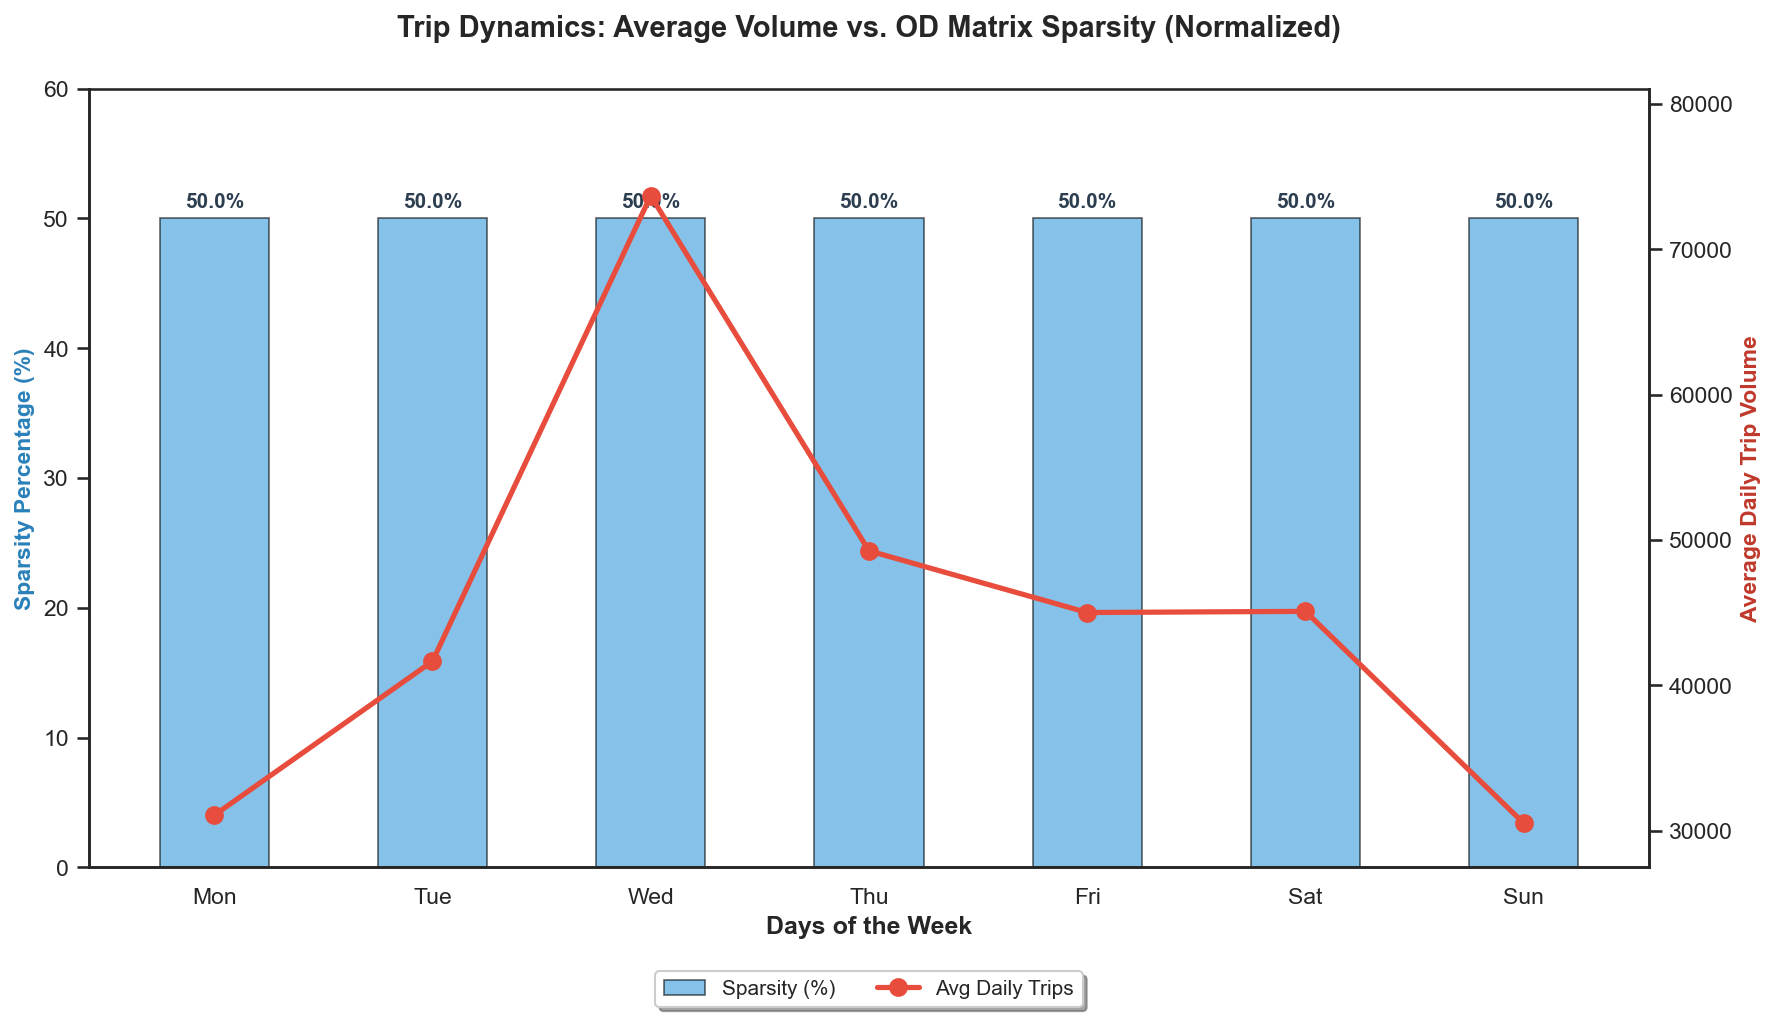

In [16]:
sns.set_theme(style="white") 
fig, ax1 = plt.subplots(figsize=(12, 7), dpi=150)
ax2 = ax1.twinx()

colors = sns.color_palette("viridis", len(sparsity_df))
days = sparsity_df.index

bars = ax1.bar(days, sparsity_df['Sparsity (%)'], color='#3498db', alpha=0.6, 
               width=0.5, label='Sparsity (%)', edgecolor='black', linewidth=0.8)

line = ax2.plot(days, sparsity_df['Total Trips (Avg)'], color='#e74c3c', marker='o', 
                markersize=8, linewidth=2.5, label='Avg Daily Trips', linestyle='-')

ax1.set_xlabel('Days of the Week', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sparsity Percentage (%)', fontsize=11, fontweight='bold', color='#2980b9')
ax2.set_ylabel('Average Daily Trip Volume', fontsize=11, fontweight='bold', color='#c0392b')

ax1.set_ylim(0, sparsity_df['Sparsity (%)'].max() * 1.2)
ax2.set_ylim(sparsity_df['Total Trips (Avg)'].min() * 0.9, sparsity_df['Total Trips (Avg)'].max() * 1.1)

plt.title('Trip Dynamics: Average Volume vs. OD Matrix Sparsity (Normalized)', 
          fontsize=14, fontweight='bold', pad=25)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.12), 
           ncol=2, frameon=True, shadow=True, fontsize=10)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height:.1f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2c3e50')
sns.despine(ax=ax1, top=True, right=False)
plt.tight_layout()
plt.show()

In [17]:
def compare_matrices_statistical(matrix_a, matrix_b):
    # Flatten matrices to 1D arrays
    a = matrix_a.values.flatten()
    b = matrix_b.values.flatten()
    
    # Filter: Keep only OD pairs where at least one day has a trip
    # This prevents the test from being dominated by thousands of zero-zero cells
    mask = (a > 0) | (b > 0)
    a_filtered = a[mask]
    b_filtered = b[mask]
    
    # Check if there's enough data to compare
    if len(a_filtered) == 0:
        return 0, 1.0 # No data means no difference
    
    # Create contingency table
    # Adding a small constant (Laplace smoothing) is good practice for sparse matrices
    obs = np.array([a_filtered, b_filtered]) + 1e-5
    
    # The test measures if the distribution of trips across OD pairs is independent of the day
    chi2, p, dof, expected = chi2_contingency(obs)
    
    return chi2, p

Detected 13 day-pairs with Significant Structural Differences (p < 0.05):
 • Mon vs Wed: Significant (p = 1.68e-02)
 • Tue vs Wed: Significant (p = 1.94e-07)
 • Tue vs Fri: Significant (p = 1.42e-05)
 • Tue vs Sat: Significant (p = 2.15e-03)
 • Tue vs Sun: Significant (p = 8.23e-03)
 • Wed vs Thu: Significant (p = 1.23e-05)
 • Wed vs Fri: Significant (p = 4.58e-09)
 • Wed vs Sat: Significant (p = 1.17e-06)
 • Wed vs Sun: Significant (p = 9.00e-03)
 • Thu vs Fri: Significant (p = 7.61e-04)
 • Thu vs Sat: Significant (p = 2.76e-02)
 • Fri vs Sat: Significant (p = 2.06e-03)
 • Fri vs Sun: Significant (p = 2.44e-02)


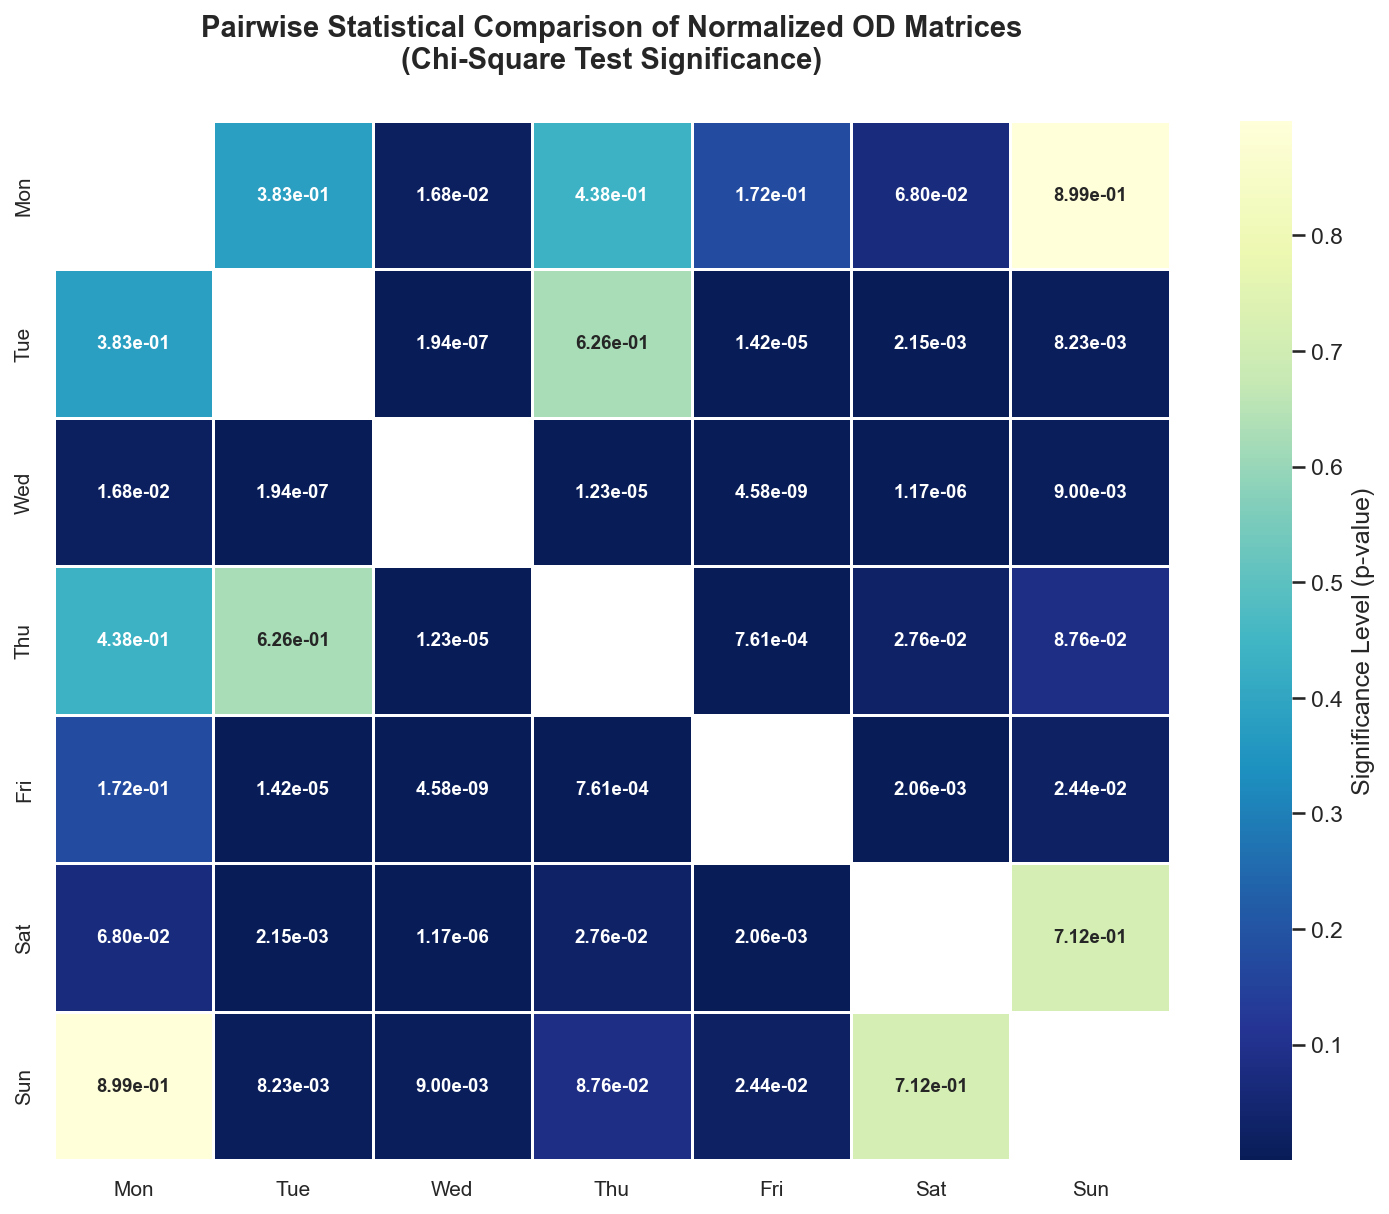

In [18]:
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
n_days = len(days)
p_values = pd.DataFrame(np.zeros((n_days, n_days)), index=days, columns=days)
significant_pairs = []

for i in range(n_days):
    for j in range(n_days):
        if i == j:
            p_values.iloc[i, j] = 1.0  
        else:
            chi2, p = compare_matrices_statistical(od_by_weekday_avg[days[i]], 
                                                  od_by_weekday_avg[days[j]])
            p_values.iloc[i, j] = p
            if i < j and p < 0.05:
                significant_pairs.append((days[i], days[j], p))

plt.figure(figsize=(12, 9), dpi=150)
sns.set_theme(style="white")

ax = sns.heatmap(p_values, annot=True, fmt=".2e", cmap="YlGnBu_r", 
                 cbar_kws={'label': 'Significance Level (p-value)'}, 
                 mask=(p_values == 1.0), linewidths=0.5, linecolor='white',
                 annot_kws={"size": 9, "weight": "bold"})

plt.title('Pairwise Statistical Comparison of Normalized OD Matrices\n(Chi-Square Test Significance)', 
          fontsize=14, fontweight='bold', pad=25)
plt.xticks(fontsize=10, fontweight='medium')
plt.yticks(fontsize=10, fontweight='medium')

if len(significant_pairs) > 0:
    print(f"Detected {len(significant_pairs)} day-pairs with Significant Structural Differences (p < 0.05):")
    for d1, d2, p in significant_pairs:
        print(f" • {d1} vs {d2}: Significant (p = {p:.2e})")
else:
    print("No significant structural differences were detected (All p-values >= 0.05).")
    print("Interpretation: The spatial distribution of trips is uniform across the week.")

plt.show()

## Part 3:

In [19]:
outflow = data['source'].value_counts()
inflow = data['destination'].value_counts()

In [20]:
zones = sorted(set(outflow.index).union(set(inflow.index)))

flow_balance = pd.DataFrame({
    'outflow': outflow.reindex(zones, fill_value=0),
    'inflow': inflow.reindex(zones, fill_value=0)
})

flow_balance

,outflow,inflow
Back Bay,57792,57780
Beacon Hill,57403,57403
Boston University,57764,57764
Fenway,57757,57757
Financial District,58857,58851
Haymarket Square,57736,57764
North End,57763,57756
North Station,57118,57119
Northeastern University,57756,57755
South Station,57750,57749


In [21]:
flow_balance['difference'] = flow_balance['inflow'] - flow_balance['outflow']
flow_balance['abs_difference'] = flow_balance['difference'].abs()

In [22]:
flow_balance[['inflow', 'outflow']].sum()

inflow     693071
outflow    693071
dtype: int64

# Question 2:

In [23]:
T0 = (
    data.groupby(["source", "destination"])
        .size()
        .unstack(fill_value=0))

T0

destination,Back Bay,Beacon Hill,Boston University,Fenway,Financial District,Haymarket Square,North End,North Station,Northeastern University,South Station,Theatre District,West End
source,,,,,,,,,,,,
Back Bay,0,0,9435,9469,0,9605,10225,0,9584,9474,0,0
Beacon Hill,0,0,9222,9436,0,9566,10039,0,9684,9456,0,0
Boston University,9435,9215,0,0,9711,0,0,9480,0,0,9967,9956
Fenway,9476,9436,0,0,9681,0,0,9751,0,0,9248,10165
Financial District,0,0,9711,9695,0,10133,9339,0,9627,10352,0,0
Haymarket Square,9605,9566,0,0,10134,0,0,9634,0,0,9641,9156
North End,10225,10039,0,0,9339,0,0,9422,0,0,9525,9213
North Station,0,0,9480,9751,0,9641,9421,0,9679,9146,0,0
Northeastern University,9579,9690,0,0,9634,0,0,9679,0,0,9644,9530


In [24]:
future = pd.DataFrame({
    "zone": [
        "Financial District",
        "Theatre District",
        "Back Bay",
        "Haymarket Square",
        "Boston University",
        "Fenway",
        "North End",
        "Northeastern University",
        "South Station",
        "West End",
        "Beacon Hill",
        "North Station"
    ],
    "O_future": [56850, 57820, 57799, 57836, 57714, 57750, 57963, 55756, 58750, 57560, 57483, 56228],
    "D_future": [59700, 59700, 58600, 56840, 59500, 56750, 58750, 56950, 58700, 56600, 58200, 56200]
})
future

,zone,O_future,D_future
0,Financial District,56850,59700
1,Theatre District,57820,59700
2,Back Bay,57799,58600
3,Haymarket Square,57836,56840
4,Boston University,57714,59500
5,Fenway,57750,56750
6,North End,57963,58750
7,Northeastern University,55756,56950
8,South Station,58750,58700
9,West End,57560,56600


In [25]:
def balance_attractions_to_productions(O, D, tol=1e-6):
    sum_O = float(np.sum(O))
    sum_D = float(np.sum(D))

    if np.isclose(sum_O, sum_D, rtol=tol):
        return D.copy(), 1.0

    k = sum_O / sum_D
    return D * k, k

In [26]:
O = future["O_future"].values.astype(float)
D = future["D_future"].values.astype(float)

D, k = balance_attractions_to_productions(O, D)

print("Scaling factor k =", k)
print("Sum O =", O.sum())
print("Sum D (balanced) =", D.sum())

Scaling factor k = 0.9899768840902239
Sum O = 689509.0
Sum D (balanced) = 689509.0000000001


In [27]:
production = future.set_index("zone")["O_future"]
attraction = future.set_index("zone")["D_future"]

## Part 1:

In [28]:
def furness_algorithm(OD_matrix, production, attraction, tolerance=1.0, max_iter=1000, verbose=True):
    zones = list(sorted(set(production.index).union(set(attraction.index))))
    T = OD_matrix.reindex(index=zones, columns=zones, fill_value=0).astype(float)
    
    total_p = production.sum()
    total_a = attraction.sum()
    k = total_p / total_a
    attraction_adj = attraction * k
    
    system_total_target = total_p 

    def compute_error(mat):
        row_sum = mat.sum(axis=1)
        col_sum = mat.sum(axis=0)
        
        origin_dev = (production - row_sum).abs().sum()
        dest_dev   = (attraction_adj - col_sum).abs().sum()
        
        return ((origin_dev + dest_dev) / system_total_target) * 100

    results = []
    err = compute_error(T)
    
    if verbose:
        print(f"Adjustment Factor (k): {k:.6f}")
        print(f"Initial Error: {err:.4f}%")

    step = 0
    while err > tolerance and step < max_iter:
        step += 1

        row_sum = T.sum(axis=1)
        row_factor = production / row_sum.replace(0, 1)
        T = T.mul(row_factor, axis=0)

        col_sum = T.sum(axis=0)
        col_factor = attraction_adj / col_sum.replace(0, 1)
        T = T.mul(col_factor, axis=1)

        err = compute_error(T)
        results.append({"iteration": step, "error_pct": err})

        if verbose and (step % 5 == 0 or step == 1):
            print(f"Iteration {step}: Error = {err:.4f}%")

    if verbose:
        if err <= tolerance:
            print(f"Convergence reached at iteration {step}.")
        else:
            print(f"Max iterations reached. Final Error: {err:.4f}%")

    return T, pd.DataFrame(results)

In [29]:
T_furness, log_furness = furness_algorithm(T0, production, attraction, tolerance=1.0, max_iter=1000)

Adjustment Factor (k): 0.989977
Initial Error: 2.5711%
Iteration 1: Error = 0.0775%
Convergence reached at iteration 1.


In [30]:
log_furness.tail()

,iteration,error_pct
0,1,0.077466


In [31]:
T_furness = np.round(T_furness, 3)
T_furness

destination,Back Bay,Beacon Hill,Boston University,Fenway,Financial District,Haymarket Square,North End,North Station,Northeastern University,South Station,Theatre District,West End
source,,,,,,,,,,,,
Back Bay,0.000,0.000,9700.227,9286.934,0.000,9436.237,10378.691,0.000,9432.542,9614.619,0.000,0.000
Beacon Hill,0.000,0.000,9493.303,9266.344,0.000,9409.880,10202.861,0.000,9543.089,9608.562,0.000,0.000
Boston University,9485.338,9262.201,0.000,0.000,9762.832,0.000,0.000,9248.133,0.000,0.000,10205.016,9702.255
Fenway,9533.654,9491.399,0.000,0.000,9739.924,0.000,0.000,9519.592,0.000,0.000,9475.901,9913.309
Financial District,0.000,0.000,9642.368,9183.238,0.000,9614.335,9155.022,0.000,9150.665,10146.183,0.000,0.000
Haymarket Square,9681.350,9639.997,0.000,0.000,10214.578,0.000,0.000,9422.801,0.000,0.000,9896.895,8945.842
North End,10324.081,10134.131,0.000,0.000,9429.517,0.000,0.000,9231.367,0.000,0.000,9794.706,9017.083
North Station,0.000,0.000,9593.462,9413.356,0.000,9322.891,9412.464,0.000,9376.472,9136.017,0.000,0.000
Northeastern University,9304.685,9410.512,0.000,0.000,9358.131,0.000,0.000,9123.192,0.000,0.000,9540.629,8973.282


## Part 2:

In [32]:
def detroit_algorithm(OD_matrix, production, attraction,
                     gf_low=0.99, gf_high=1.01,
                     max_iter=1000, verbose=True):


    zones = list(sorted(set(OD_matrix.index).union(set(OD_matrix.columns))))
    T0 = OD_matrix.reindex(index=zones, columns=zones, fill_value=0).astype(float)

    production = production.reindex(zones).astype(float)
    attraction = attraction.reindex(zones).astype(float)

    if production.isna().any() or attraction.isna().any():
        missing_p = production[production.isna()].index.tolist()
        missing_a = attraction[attraction.isna()].index.tolist()
        raise ValueError(f"Missing zones in production/attraction. prod missing: {missing_p}, attr missing: {missing_a}")

    A_bal_values, k = balance_attractions_to_productions(production.values, attraction.values)
    attraction_bal = pd.Series(A_bal_values, index=zones)

    T = T0.copy()
    results = []

    def growth_factors(mat):
        row_sum = mat.sum(axis=1)
        col_sum = mat.sum(axis=0)

        a = pd.Series(1.0, index=zones)  # origin factors
        b = pd.Series(1.0, index=zones)  # destination factors

        nz_r = row_sum != 0
        nz_c = col_sum != 0

        a.loc[nz_r] = production.loc[nz_r] / row_sum.loc[nz_r]
        b.loc[nz_c] = attraction_bal.loc[nz_c] / col_sum.loc[nz_c]

        return a, b, row_sum, col_sum, nz_r, nz_c

    def in_range(a, b, nz_r, nz_c):
        ok_a = ((a.loc[nz_r] > gf_low) & (a.loc[nz_r] < gf_high)).all()
        ok_b = ((b.loc[nz_c] > gf_low) & (b.loc[nz_c] < gf_high)).all()
        return bool(ok_a and ok_b)
        
    a, b, row_sum, col_sum, nz_r, nz_c = growth_factors(T)
    conv0 = in_range(a, b, nz_r, nz_c)
    total_trips = float(T.to_numpy().sum())

    if verbose:
        print(f"Attraction scaling factor k = {k:.6f}")
        print(f"Iteration 0: Total Trips = {total_trips:.2f}, "
              f"a range=({a.loc[nz_r].min():.4f},{a.loc[nz_r].max():.4f}), "
              f"b range=({b.loc[nz_c].min():.4f},{b.loc[nz_c].max():.4f}), "
              f"Converged={conv0}")

    results.append({
        "iteration": 0,
        "total_trips": total_trips,
        "a_min": float(a.loc[nz_r].min()) if nz_r.any() else np.nan,
        "a_max": float(a.loc[nz_r].max()) if nz_r.any() else np.nan,
        "b_min": float(b.loc[nz_c].min()) if nz_c.any() else np.nan,
        "b_max": float(b.loc[nz_c].max()) if nz_c.any() else np.nan,
        "converged": conv0
    })

    step = 0
    total_target = float(production.sum()) 

    while (not conv0) and step < max_iter:
        step += 1

        a, b, *_ = growth_factors(T)

        total_trips = float(T.to_numpy().sum())
        if total_trips <= 0:
            raise ValueError("Total trips became zero/non-positive; cannot compute f_avg.")

        f_avg = total_target / total_trips

        factor_matrix = (a.to_numpy().reshape(-1, 1) * b.to_numpy().reshape(1, -1)) / f_avg
        T = T.to_numpy() * factor_matrix
        T = pd.DataFrame(T, index=zones, columns=zones)

        a2, b2, _, _, nz_r2, nz_c2 = growth_factors(T)
        conv = in_range(a2, b2, nz_r2, nz_c2)

        total_trips2 = float(T.to_numpy().sum())

        if verbose:
            print(f"Iteration {step}: Total Trips = {total_trips2:.2f}, "
                  f"a range=({a2.loc[nz_r2].min():.4f},{a2.loc[nz_r2].max():.4f}), "
                  f"b range=({b2.loc[nz_c2].min():.4f},{b2.loc[nz_c2].max():.4f}), "
                  f"F_avg={f_avg:.6f}, Converged={conv}")

        results.append({
            "iteration": step,
            "total_trips": total_trips2,
            "a_min": float(a2.loc[nz_r2].min()) if nz_r2.any() else np.nan,
            "a_max": float(a2.loc[nz_r2].max()) if nz_r2.any() else np.nan,
            "b_min": float(b2.loc[nz_c2].min()) if nz_c2.any() else np.nan,
            "b_max": float(b2.loc[nz_c2].max()) if nz_c2.any() else np.nan,
            "f_avg": float(f_avg),
            "converged": conv
        })

        conv0 = conv

    if verbose:
        if conv0:
            print(f"Convergence reached at iteration {step} (growth factors in ({gf_low},{gf_high}))")
        else:
            print(f"Stopped at max_iter={max_iter} without meeting growth-factor criterion.")

    log_frame = pd.DataFrame(results)
    return T, log_frame

In [33]:
T_detroit, log_detroit = detroit_algorithm(
    T0, production, attraction,
    gf_low=0.99, gf_high=1.01,
    max_iter=1000, verbose=True
)

Attraction scaling factor k = 0.989977
Iteration 0: Total Trips = 693071.00, a range=(0.9654,1.0173), b range=(0.9727,1.0226), Converged=False
Iteration 1: Total Trips = 689514.27, a range=(0.9975,1.0025), b range=(0.9968,1.0032), F_avg=0.994861, Converged=True
Convergence reached at iteration 1 (growth factors in (0.99,1.01))


In [34]:
T_detroit = np.round(T_detroit, 3)
T_detroit

,Back Bay,Beacon Hill,Boston University,Fenway,Financial District,Haymarket Square,North End,North Station,Northeastern University,South Station,Theatre District,West End
Back Bay,0.000,0.000,9672.017,9259.356,0.000,9406.101,10351.172,0.000,9405.164,9583.904,0.000,0.000
Beacon Hill,0.000,0.000,9465.695,9238.827,0.000,9379.828,10175.808,0.000,9515.390,9577.866,0.000,0.000
Boston University,9513.684,9289.033,0.000,0.000,9794.250,0.000,0.000,9273.652,0.000,0.000,10235.587,9730.925
Fenway,9562.145,9518.895,0.000,0.000,9771.268,0.000,0.000,9545.860,0.000,0.000,9504.287,9942.602
Financial District,0.000,0.000,9614.326,9155.967,0.000,9583.630,9130.747,0.000,9124.106,10113.770,0.000,0.000
Haymarket Square,9710.282,9667.923,0.000,0.000,10247.449,0.000,0.000,9448.802,0.000,0.000,9926.542,8972.277
North End,10354.934,10163.489,0.000,0.000,9459.862,0.000,0.000,9256.840,0.000,0.000,9824.048,9043.728
North Station,0.000,0.000,9565.563,9385.402,0.000,9293.116,9387.507,0.000,9349.257,9106.832,0.000,0.000
Northeastern University,9332.491,9437.773,0.000,0.000,9388.246,0.000,0.000,9148.366,0.000,0.000,9569.210,8999.797
South Station,9712.476,9706.452,0.000,0.000,10630.739,0.000,0.000,9116.705,0.000,0.000,10218.994,9508.935


## Part 3:

In [35]:
def fratar_algorithm(OD_matrix, production, attraction, tolerance=1.0, max_iter=1000, verbose=True):

    updated_matrix = OD_matrix.copy().astype(float)
    region_list = list(OD_matrix.index)

    production = production.reindex(region_list).astype(float)
    attraction = attraction.reindex(region_list).astype(float)

    if production.isna().any() or attraction.isna().any():
        missing_p = production[production.isna()].index.tolist()
        missing_a = attraction[attraction.isna()].index.tolist()
        raise ValueError(f"Missing zones in production/attraction. prod missing: {missing_p}, attr missing: {missing_a}")
        
    attraction_bal_values, k = balance_attractions_to_productions(production.values, attraction.values)
    attraction_bal = pd.Series(attraction_bal_values, index=region_list)

    system_total_target = production.sum()

    results = []

    def compute_error(mat):
        origins_sum = mat.sum(axis=1)
        destinations_sum = mat.sum(axis=0)
        origin_dev = (production - origins_sum).abs().sum()
        dest_dev = (attraction_bal - destinations_sum).abs().sum()
        return ((origin_dev + dest_dev) / system_total_target) * 100

    deviation = compute_error(updated_matrix)
    trips_total = updated_matrix.to_numpy().sum()

    if verbose:
        print(f"Attraction scaling factor k = {k:.6f}")
        print(f"Iteration 0: Total Trips = {trips_total:.2f}, Error = {deviation:.4f}%")

    results.append({"iteration": 0, "total_trips": trips_total, "error_pct": deviation})

    step = 0
    while deviation > tolerance and step < max_iter:
        step += 1

        destination_totals = updated_matrix.sum(axis=0)

        growth_factors = pd.Series(1.0, index=region_list)
        nonzero_mask = destination_totals != 0
        growth_factors.loc[nonzero_mask] = attraction_bal.loc[nonzero_mask] / destination_totals.loc[nonzero_mask]

        refreshed_matrix = pd.DataFrame(0.0, index=region_list, columns=region_list)

        for origin_reg in region_list:
            weights = updated_matrix.loc[origin_reg, :] * growth_factors
            weights_sum = float(weights.sum())

            if weights_sum > 0:
                refreshed_matrix.loc[origin_reg, :] = production.loc[origin_reg] * (weights / weights_sum)
            else:
                refreshed_matrix.loc[origin_reg, :] = production.loc[origin_reg] / len(region_list)

        updated_matrix = refreshed_matrix

        deviation = compute_error(updated_matrix)
        trips_total = updated_matrix.to_numpy().sum()

        if verbose:
            print(f"Iteration {step}: Total Trips = {trips_total:.2f}, Error = {deviation:.4f}%")

        results.append({"iteration": step, "total_trips": trips_total, "error_pct": deviation})

    if verbose:
        if deviation <= tolerance:
            print(f"Convergence reached at iteration {step}")
        else:
            print(f"Stopped at max_iter={max_iter}. Final error = {deviation:.4f}%")

    log_frame = pd.DataFrame(results)
    return updated_matrix, log_frame

In [36]:
T_fratar, log_fratar = fratar_algorithm(T0, production, attraction, tolerance=1.0, max_iter=1000)

Attraction scaling factor k = 0.989977
Iteration 0: Total Trips = 693071.00, Error = 2.5711%
Iteration 1: Total Trips = 689509.00, Error = 0.0775%
Convergence reached at iteration 1


In [37]:
log_fratar.tail()

,iteration,total_trips,error_pct
0,0,693071.0,2.571090
1,1,689509.0,0.077466


In [38]:
T_fratar = np.round(T_fratar, 3)
T_fratar

,Back Bay,Beacon Hill,Boston University,Fenway,Financial District,Haymarket Square,North End,North Station,Northeastern University,South Station,Theatre District,West End
Back Bay,0.000,0.000,9692.356,9278.827,0.000,9425.880,10372.939,0.000,9424.942,9604.057,0.000,0.000
Beacon Hill,0.000,0.000,9487.082,9259.702,0.000,9401.021,10198.799,0.000,9536.889,9599.507,0.000,0.000
Boston University,9493.430,9269.257,0.000,0.000,9773.399,0.000,0.000,9253.909,0.000,0.000,10213.796,9710.209
Fenway,9546.432,9503.252,0.000,0.000,9755.210,0.000,0.000,9530.174,0.000,0.000,9488.669,9926.264
Financial District,0.000,0.000,9635.929,9176.541,0.000,9605.164,9151.264,0.000,9144.607,10136.495,0.000,0.000
Haymarket Square,9687.289,9645.030,0.000,0.000,10223.184,0.000,0.000,9426.428,0.000,0.000,9903.037,8951.031
North End,10330.001,10139.017,0.000,0.000,9437.085,0.000,0.000,9234.552,0.000,0.000,9800.393,9021.953
North Station,0.000,0.000,9589.494,9408.883,0.000,9316.366,9410.993,0.000,9372.648,9129.616,0.000,0.000
Northeastern University,9312.468,9417.524,0.000,0.000,9368.103,0.000,0.000,9128.738,0.000,0.000,9548.679,8980.488
South Station,9688.678,9682.669,0.000,0.000,10604.692,0.000,0.000,9094.368,0.000,0.000,10193.956,9485.637


## Part 4:

### Part A:

In [39]:
cost_col = "price"   
C_df = (
    data.groupby(["source", "destination"])[cost_col]
        .mean()
        .unstack()
)

C_df = C_df.reindex(index=zones, columns=zones)

np.fill_diagonal(C_df.values, 0.0)

In [40]:
global_mean_cost = np.nanmean(C_df.values)
C_df = C_df.fillna(global_mean_cost)

C = C_df.to_numpy()

In [41]:
def impedance_matrix(C, beta=0.2, alpha=0.05):
    """
    Exponential deterrence:
    F_ij = exp(-beta * alpha * C_ij)
    beta = 0.2 (given)
    alpha = 0.05 (given)
    """
    C = np.asarray(C, dtype=float)
    return alpha * np.exp(-beta * C)

F = impedance_matrix(C, beta=0.2, alpha=0.05)

In [42]:
df_F = pd.DataFrame(F, index=[f"i={z}" for z in zones], columns=[f"j={z}" for z in zones])
df_F = np.round(df_F, 3)
df_F

,j=Back Bay,j=Beacon Hill,j=Boston University,j=Fenway,j=Financial District,j=Haymarket Square,j=North End,j=North Station,j=Northeastern University,j=South Station,j=Theatre District,j=West End
i=Back Bay,0.050,0.003,0.003,0.003,0.003,0.001,0.001,0.003,0.004,0.001,0.003,0.003
i=Beacon Hill,0.003,0.050,0.002,0.002,0.003,0.003,0.002,0.003,0.002,0.002,0.003,0.003
i=Boston University,0.003,0.002,0.050,0.003,0.000,0.003,0.003,0.001,0.003,0.003,0.001,0.001
i=Fenway,0.003,0.002,0.003,0.050,0.000,0.003,0.003,0.001,0.003,0.003,0.001,0.001
i=Financial District,0.003,0.003,0.000,0.000,0.050,0.004,0.004,0.003,0.001,0.004,0.003,0.003
i=Haymarket Square,0.002,0.003,0.003,0.003,0.004,0.050,0.003,0.004,0.003,0.003,0.003,0.004
i=North End,0.001,0.002,0.003,0.003,0.003,0.003,0.050,0.004,0.003,0.003,0.002,0.003
i=North Station,0.003,0.003,0.001,0.001,0.003,0.004,0.004,0.050,0.001,0.002,0.003,0.003
i=Northeastern University,0.003,0.002,0.003,0.003,0.001,0.003,0.003,0.001,0.050,0.003,0.002,0.001
i=South Station,0.001,0.002,0.003,0.003,0.004,0.003,0.003,0.002,0.003,0.050,0.003,0.002


In [43]:
def gravity(O, D, F, max_iter=1000, threshold=0.01):
    """
    O: productions (n,)
    D: attractions (n,) (already balanced to sum(O))
    F: impedance matrix (n,n)
    """
    
    O = np.asarray(O, dtype=float)
    D = np.asarray(D, dtype=float)
    F = np.asarray(F, dtype=float)

    n = len(O)
    B = np.ones(n, dtype=float)
    history = []
    T = np.zeros((n, n), dtype=float)

    total = float(O.sum()) 

    for it in range(max_iter):
        A = 1.0 / np.sum(F * (B * D), axis=1)
        B = 1.0 / np.sum(((A * O)[:, None] * F), axis=0)
        T = (A * O)[:, None] * (B * D)[None, :] * F

        row_sum = T.sum(axis=1)
        col_sum = T.sum(axis=0)
        
        err_O = np.abs(row_sum - O).sum()
        err_D = np.abs(col_sum - D).sum()
        total_trips = O.sum()

        error = (err_O + err_D) / total_trips * 100
        history.append(error)

        if error < threshold:
            print(f"Converged! at iteration: {it+1} with Error: {error:.4f}%")
            break

    final_OD = pd.DataFrame(T, columns=zones, index=zones)
    return final_OD, history, A, B

In [44]:
final_OD_gravity, history_gravity_exp, A, B = gravity(
    O=production,
    D=D,
    F=F,
    max_iter=1000,
    threshold=1.0  
)

Converged! at iteration: 1 with Error: 0.9810%


In [45]:
final_OD_gravity = np.round(final_OD_gravity, 3)
final_OD_gravity

,Back Bay,Beacon Hill,Boston University,Fenway,Financial District,Haymarket Square,North End,North Station,Northeastern University,South Station,Theatre District,West End
Back Bay,37236.913,2204.843,2207.934,2268.696,2174.489,929.759,716.507,2096.529,2601.875,963.489,2090.659,2041.303
Beacon Hill,2239.104,38365.240,1415.133,1407.511,2224.271,2197.797,1698.395,2144.526,1369.872,1398.572,2138.522,2088.036
Boston University,2505.602,1298.485,40436.150,2263.436,326.680,2204.666,2286.827,695.492,2345.195,2157.342,935.398,927.636
Fenway,2631.692,1456.358,2403.276,38927.972,380.468,2228.981,2312.049,774.555,2371.061,2181.135,1036.192,1026.182
Financial District,2255.677,2272.012,229.985,332.870,38117.131,2501.812,2599.501,2160.399,464.280,2895.462,2154.350,2103.490
Haymarket Square,1229.373,2504.542,2069.644,1970.715,2788.856,32653.387,1991.081,2912.278,2041.901,1878.342,2219.288,2725.846
North End,747.177,1536.372,2154.392,2051.413,2530.882,1998.147,35257.210,2747.683,2125.513,1955.256,1714.106,2339.430
North Station,2220.409,2236.489,841.874,865.616,2205.700,2785.814,2596.488,36175.940,735.740,1556.375,2120.666,2070.602
Northeastern University,2646.186,1421.387,2367.132,2253.983,444.786,2195.458,2277.276,731.659,39727.508,2148.332,1549.577,1002.224
South Station,849.110,1232.634,2238.873,2131.856,3200.060,2076.502,2153.887,1591.526,2208.862,34565.137,2272.137,1508.494


### Part B:

In [46]:
def impedance_matrix_logit(C,  alpha=-3.0, beta=2.0):
    """
    Log-Logistic Deterrence Function:
    F_ij = 1 / (1 + exp(alpha + beta * ln(C_ij)))
    """
    C = np.asarray(C, dtype=float)
    C_safe = np.where(C <= 0, 1.0, C)
    exponent = alpha + beta * np.log(C_safe)
    F = 1.0 / (1.0 + np.exp(exponent))
    return F

In [47]:
F_logit = impedance_matrix_logit(C, alpha=-3.0, beta=2.0)

final_OD_logit, history_gravity_logit, A, B = gravity(
    O=O,
    D=D,
    F=F_logit,
    max_iter=1000,
    threshold=1.0 
)

Converged! at iteration: 1 with Error: 0.7426%


In [48]:
def find_fastest_params(O, D, C):
    best_alpha = None
    best_beta = None
    min_iters = float('inf')
    best_error = float('inf')
    
    alpha_range = np.linspace(-10, 2, 100) 
    beta_range = np.linspace(0.5, 3.0, 100)

    print("Searching for the fastest parameters...")
    
    for a in alpha_range:
        for b in beta_range:
            C_safe = np.where(C <= 0, 1.0, C)
            exponent = a + b * np.log(C_safe)
            F_test = 1.0 / (1.0 + np.exp(exponent))
            _, history, _, _ = gravity(O, D, F_test, max_iter=100, threshold=1.0)
            iters = len(history)
            final_err = history[-1]

            if iters < min_iters or (iters == min_iters and final_err < best_error):
                min_iters = iters
                best_error = final_err
                best_alpha = a
                best_beta = b
                
    print(f"\n--- Best Parameters Found ---")
    print(f"Alpha: {best_alpha}")
    print(f"Beta: {best_beta}")
    print(f"Minimum Iterations: {min_iters}")
    print(f"Final Error: {best_error:.4f}%")
    
    return best_alpha, best_beta

In [49]:
best_alpha, best_beta = find_fastest_params(production, attraction, C)
F_optimal = impedance_matrix_logit(C, alpha=best_alpha, beta=best_beta)
final_OD, history_gravity_logit, A, B = gravity(O, D, F_optimal, threshold=1.0)

Searching for the fastest parameters...

--- Best Parameters Found ---
Alpha: -1.7575757575757578
Beta: 0.9292929292929293
Minimum Iterations: 100
Final Error: 1.0125%
Converged! at iteration: 1 with Error: 0.1657%


In [50]:
final_OD = np.round(final_OD, 3)
final_OD

,Back Bay,Beacon Hill,Boston University,Fenway,Financial District,Haymarket Square,North End,North Station,Northeastern University,South Station,Theatre District,West End
Back Bay,11365.518,4422.991,4491.751,4390.432,4467.352,3483.210,3448.160,4246.422,4617.140,3537.016,4282.334,4155.654
Beacon Hill,4471.274,11590.214,4135.808,4009.099,4535.852,4192.595,4108.598,4311.535,4068.656,3844.200,4347.997,4219.375
Boston University,4724.578,4140.563,12270.350,4568.853,3327.443,4324.245,4515.518,3585.677,4694.765,4344.411,3810.121,3707.792
Fenway,4754.751,4215.157,4744.281,11766.682,3391.447,4315.096,4505.964,3637.892,4684.832,4335.219,3865.670,3761.094
Financial District,4577.753,4597.756,3123.595,3191.677,11985.238,4413.204,4610.235,4414.210,3434.765,4612.740,4451.541,4319.856
Haymarket Square,3861.341,4498.056,4375.882,4205.160,4673.208,10271.937,4156.071,4527.544,4321.049,3998.584,4288.582,4389.002
North End,3593.553,4124.990,4495.431,4320.045,4650.468,4088.758,11019.334,4543.613,4439.100,4107.826,4129.530,4310.811
North Station,4364.410,4383.481,3667.476,3573.334,4427.445,4330.878,4410.237,10861.577,3544.993,3841.910,4244.080,4118.532
Northeastern University,4800.296,4228.354,4767.611,4581.605,3499.025,4336.315,4528.122,3629.534,12150.413,4356.537,4208.097,3773.714
South Station,3683.569,3956.570,4536.286,4359.306,4912.962,4125.917,4308.417,4034.724,4479.443,10698.127,4391.427,3926.963


## Part 5:

In [51]:
comparison_data = [
    {
        "Algorithm": "Furness", 
        "Iterations": len(log_furness), 
        "Final Error (%)": log_furness["error_pct"].iloc[-1]
    },
    {
        "Algorithm": "Detroit", 
        "Iterations": len(log_detroit) - 1, 
        "Final Error (%)": f"[{log_detroit['a_min'].iloc[-1]:.3f}, {log_detroit['a_max'].iloc[-1]:.3f}]"
    },
    {
        "Algorithm": "Fratar", 
        "Iterations": len(log_fratar) - 1, 
        "Final Error (%)": log_fratar["error_pct"].iloc[-1]
    },
    {
        "Algorithm": "Gravity (Exp)", 
        "Iterations": len(history_gravity_exp), 
        "Final Error (%)": history_gravity_exp[-1]
    },
    {
        "Algorithm": "Gravity (Log-Log)", 
        "Iterations": len(history_gravity_logit), 
        "Final Error (%)": history_gravity_logit[-1]
    }
]

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Algorithm,Iterations,Final Error (%)
0,Furness,1,0.077466
1,Detroit,1,"[0.998, 1.003]"
2,Fratar,1,0.077466
3,Gravity (Exp),1,0.981031
4,Gravity (Log-Log),1,0.165664


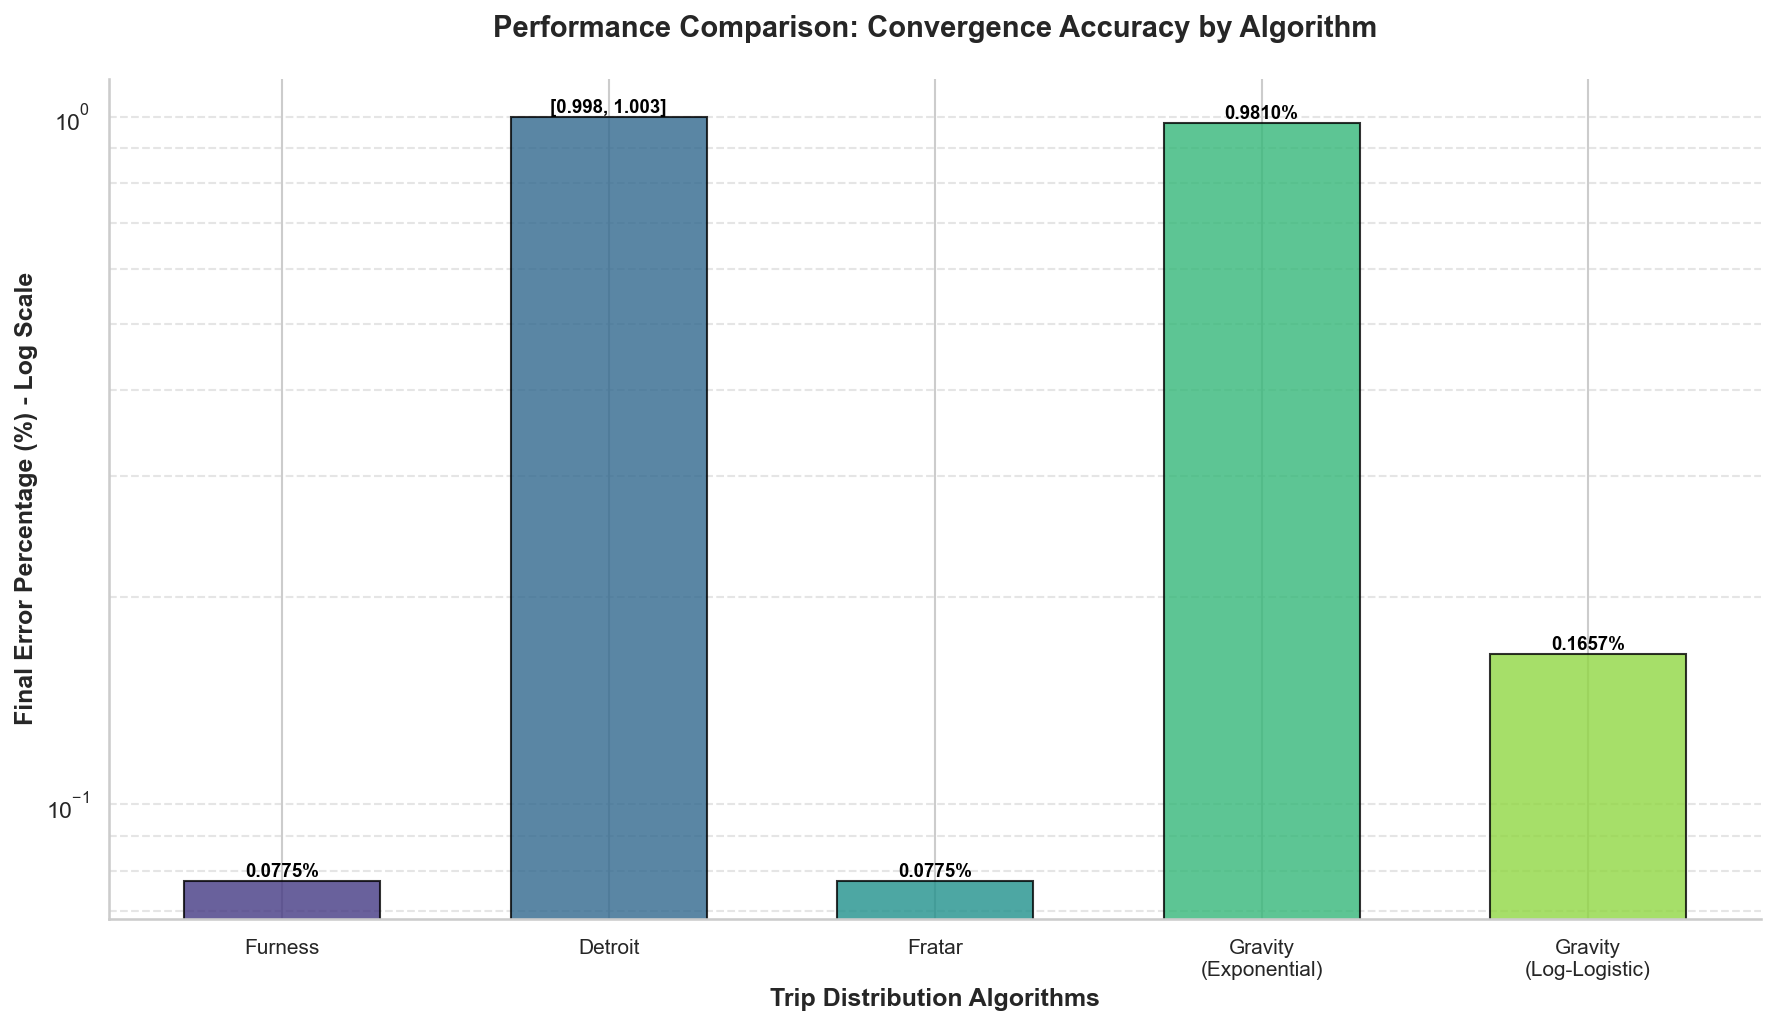

In [52]:
plot_df = comparison_df.copy()

def extract_numeric_error(val):
    if isinstance(val, str):
        return 1.0 
    return float(val)

plot_df['Error_Numeric'] = plot_df['Final Error (%)'].apply(extract_numeric_error)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7), dpi=150)

algo_names = ['Furness', 'Detroit', 'Fratar', 'Gravity\n(Exponential)', 'Gravity\n(Log-Logistic)']

colors = sns.color_palette("viridis", len(plot_df))
bars = plt.bar(algo_names, plot_df['Error_Numeric'], 
               color=colors, edgecolor='black', alpha=0.8, width=0.6)

for i, bar in enumerate(bars):
    original_val = comparison_df['Final Error (%)'].iloc[i]
    label = f'{original_val:.4f}%' if isinstance(original_val, (float, int)) else original_val
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             label, va='bottom', ha='center', 
             fontsize=9, fontweight='bold', color='black')

plt.yscale('log') 
plt.ylabel('Final Error Percentage (%) - Log Scale', fontsize=12, fontweight='bold')
plt.xlabel('Trip Distribution Algorithms', fontsize=12, fontweight='bold')
plt.title('Performance Comparison: Convergence Accuracy by Algorithm', fontsize=14, fontweight='bold', pad=20)

plt.grid(axis='y', which='both', linestyle='--', alpha=0.5)
plt.xticks(fontsize=10, fontweight='medium')
sns.despine()
plt.tight_layout()
plt.show()

# Question 3:

In [53]:
# --- STEP 1: Prep Data & Temporal Indices ---
data['time_block'] = pd.cut(data['hour'], bins=[0, 6, 12, 18, 24], labels=[1, 2, 3, 4], right=False).astype(int)
day_order = {'Sat': 0, 'Sun': 1, 'Mon': 2, 'Tue': 3, 'Wed': 4, 'Thu': 5, 'Fri': 6}
data['day_num'] = data['weekday_name'].map(day_order)
data['t'] = (data['day_num'] * 4) + data['time_block']

# --- STEP 2: Normalization Logic (Average Daily Demand) ---
# Count how many of each weekday exist in the dataset
day_counts = data.groupby('day_num')['date'].nunique().to_dict()
t_occurrence_map = {t: day_counts[(t-1)//4] for t in range(1, 29)}

# Calculate Mean Price, Distance, and Normalized Demand
price_param = data.groupby(['source', 'destination', 't'])['price'].mean().to_dict()
dist_param = data.groupby(['source', 'destination'])['distance'].mean().to_dict()

total_demand = data.groupby(['source', 'destination', 't']).size().reset_index(name='total_trips')
total_demand['avg_daily_demand'] = total_demand.apply(
    lambda x: x['total_trips'] / t_occurrence_map.get(x['t'], 1), axis=1
)
demand_param = total_demand.set_index(['source', 'destination', 't'])['avg_daily_demand'].to_dict()

# --- STEP 3: Optimization Model ---
model = pulp.LpProblem("Final_Revenue_Optimization", pulp.LpMaximize)
keys = price_param.keys()
q = pulp.LpVariable.dicts("q", keys, lowBound=0, cat='Integer')

# Objective: Maximize expected revenue
model += pulp.lpSum([price_param[k] * q[k] for k in keys])

# Constraints
for k in keys:
    model += q[k] <= demand_param.get(k, 0)

weekend_keys = [k for k in keys if k[2] <= 8]
if weekend_keys: model += pulp.lpSum([q[k] for k in weekend_keys]) == 0

workday_ranges = {"Mon": range(9, 13), "Tue": range(13, 17), "Wed": range(17, 21), "Thu": range(21, 25), "Fri": range(25, 29)}
for day, t_range in workday_ranges.items():
    day_keys = [k for k in keys if k[2] in t_range]
    if day_keys:
        model += pulp.lpSum([dist_param[(k[0], k[1])] * q[k] for k in day_keys]) <= 20

# Solve
model.solve(pulp.PULP_CBC_CMD(msg=0))

# --- STEP 4: Detailed Result Extraction ---
results = []
for k in keys:
    if q[k].varValue > 0:
        dist = dist_param.get((k[0], k[1]), 0)
        demand = demand_param.get(k, 0)
        served = q[k].varValue
        results.append({
            'Source': k[0],
            'Destination': k[1],
            't': k[2],
            'Avg_Daily_Demand': round(demand, 2),
            'Served_Trips': int(served),
            'Price_Per_Trip': round(price_param[k], 2),
            'Distance_KM': round(dist, 2),
            'Total_Distance_Used': round(served * dist, 2),
            'Revenue': round(served * price_param[k], 2)
        })

res_df = pd.DataFrame(results).sort_values(by=['t', 'Revenue'], ascending=[True, False])

print(f"Status: {pulp.LpStatus[model.status]}")
print(f"Total Weekly Revenue: ${pulp.value(model.objective):,.2f}")

Status: Optimal
Total Weekly Revenue: $2,963.83


In [54]:
res_df

,Source,Destination,t,Avg_Daily_Demand,Served_Trips,Price_Per_Trip,Distance_KM,Total_Distance_Used,Revenue
6,Theatre District,South Station,9,81.75,2,13.73,0.59,1.17,27.46
0,Financial District,South Station,10,110.00,45,13.18,0.42,18.82,593.23
1,Financial District,South Station,14,167.67,45,12.68,0.42,18.82,570.45
7,Theatre District,South Station,14,162.00,2,13.21,0.59,1.17,26.43
5,Haymarket Square,North Station,17,61.00,3,12.93,0.51,1.54,38.78
2,Financial District,South Station,19,456.00,44,11.97,0.42,18.40,526.53
3,Financial District,South Station,22,178.50,45,12.74,0.42,18.82,573.18
8,Theatre District,South Station,22,164.00,2,13.33,0.59,1.17,26.65
4,Financial District,South Station,25,147.50,45,12.33,0.42,18.82,554.97
9,Theatre District,South Station,25,163.00,2,13.08,0.59,1.17,26.16
